In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString

In [3]:
is2_profile_csv = "C:/Users/yhqian/Downloads/QGIS_maps/PointClouds_2_Raster/ALS_L1B_20190410T174554_181213_3/ridges_pts_peaks_ICESat-2/UMDRDA_ATL03_20190410152144_01890303_007_01_gt2l_DTU21_Elevation_epsg3413_drift_correct_dx0128.5_dy05.91_0305_crop.csv"      # has header: x_3413_dc,y_3413_dc,ele
oib_profile_txt = "C:/Users/yhqian/Downloads/QGIS_maps/PointClouds_2_Raster/ALS_L1B_20190410T174554_181213_3/ridges_pts_peaks_ICESat-2/UMDRDA_ATL03_20190410152144_01890303_007_01_gt2l_DTU21_Elevation_epsg3413_drift_correct_xy_dx0128.5_dy05.91_dz0.24_TTL_ALS.txt"      # no header: x y z (interpolated)
# Peak points
is2_peaks_csv = "C:/Users/yhqian/Downloads/QGIS_maps/PointClouds_2_Raster/ICESat-2/strong_beams/QGIS_partition/UMDRDA_ATL03_20190410152144_01890303_007_01_gt2l_DTU21_ModifiedYuehui_SailHeight_subset_FINAL_epsg3413_drift_correct_dx0128.5_dy05.91_0420.csv"      # has header: x_3413_dc,y_3413_dc,ele
oib_peaks_txt = "C:/Users/yhqian/Downloads/ridge_paper_results/ALS_L1B_20190410T174554_181213_3/ICESat2_peaks/UMDRDA_ATL03_ALS_L1B_20190410T174554_181213_3_intersect_TTL_ALS_rename_04202026_20m_visual.txt"      # no header: x y z (interpolated)

In [4]:
def build_track_from_is2(df_is2_xy, xcol="x", ycol="y"):
    coords = list(zip(df_is2_xy[xcol].to_numpy(), df_is2_xy[ycol].to_numpy()))
    line = LineString(coords)
    if line.length == 0:
        raise ValueError("Track LineString has zero length. Check IS2 ordering / coordinates.")
    return line

def project_distance(df, line, xcol="x", ycol="y", outcol="distance"):
    # vectorized-ish apply; fine for typical profile lengths
    df[outcol] = df.apply(lambda r: line.project(Point(r[xcol], r[ycol])), axis=1)
    return df

#### 1) Read the two profile lines

In [5]:
# ICESat-2 profile (CSV with header)
df_is2_line = pd.read_csv(is2_profile_csv)
df_is2_line = df_is2_line.rename(columns={"x_3413_dc":"x", "y_3413_dc":"y", "ele":"z"})

df_is2_line = df_is2_line[["x","y","z"]].dropna()
df_is2_line["dataset"] = "ICESat-2 profile"

# OIB/TIN profile (TXT no header)
df_oib_line = pd.read_csv(oib_profile_txt, sep=r"\s+", header=None, names=["x","y","z"])

# for partition only
# df_oib_line = pd.read_csv(oib_profile_txt)
# df_oib_line = df_oib_line.rename(columns={"field_1":"x", "field_2":"y", "field_3":"z"})

df_oib_line = df_oib_line.dropna()
df_oib_line["dataset"] = "IceBridge TIN"

#### 2) Build reference track from ICESat-2 profile points (must be in along-track order)

In [6]:
track = build_track_from_is2(df_is2_line, "x", "y")

#### 3) Compute along-track distance for line points

In [7]:
df_is2_line = project_distance(df_is2_line, track)
print("df_is2_line columns: ", df_is2_line.columns)

df_oib_line = project_distance(df_oib_line, track)
print("df_oib_line columns: ", df_oib_line.columns)

df_is2_line columns:  Index(['x', 'y', 'z', 'dataset', 'distance'], dtype='object')
df_oib_line columns:  Index(['x', 'y', 'z', 'dataset', 'distance'], dtype='object')


#### 4) Read the two peak point sets

In [8]:
# ICESat-2 ridge peaks (CSV header)
df_is2_peaks = pd.read_csv(is2_peaks_csv).rename(columns={"x_3413_dc":"x","y_3413_dc":"y","ele":"z"})
df_is2_peaks = df_is2_peaks[["x","y","z"]].dropna()
df_is2_peaks["dataset"] = "ICESat-2 peaks"

# IceBridge peaks (TXT no header)
if Path(oib_peaks_txt).suffix == '.csv':
    df_oib_peaks = pd.read_csv(oib_peaks_txt).rename(columns={"ele":"z"})
else:
    df_oib_peaks = pd.read_csv(oib_peaks_txt, sep=r"\s+", header=None, names=["x","y","z"])

df_oib_peaks = df_oib_peaks.dropna()
df_oib_peaks["dataset"] = "IceBridge peaks"

#### 5) Compute along-track distance for peak points

In [9]:
df_is2_peaks = project_distance(df_is2_peaks, track)
print("df_is2_peaks columns: ", df_is2_peaks.columns)

df_oib_peaks = project_distance(df_oib_peaks, track)
print("df_oib_peaks columns: ", df_oib_peaks.columns)

df_is2_peaks columns:  Index(['x', 'y', 'z', 'dataset', 'distance'], dtype='object')
df_oib_peaks columns:  Index(['x', 'y', 'z', 'dataset', 'distance'], dtype='object')


In [10]:
# filter df_oib_peaks to remove peaks whose 'z' is smaller than 0.5m (HA)
df_oib_peaks = df_oib_peaks[df_oib_peaks['z'] >= 0.5003]

#### 6) Sort (important for line drawing)

In [11]:
df_is2_line = df_is2_line.sort_values("distance")
df_oib_line = df_oib_line.sort_values("distance")

#### 7) Plot: two lines + two scatter overlays

In [13]:
# dx10.957646_dy13.968103
plt.rcParams.update({
    "font.family": "Times New Roman",
    "figure.dpi": 1200,
})

fig, ax = plt.subplots(figsize=(10, 4))

df_is2_line_cp = df_is2_line.copy(deep=True)
df_is2_line_cp["z"] -= 0

# lines
ax.plot(df_is2_line_cp["distance"], df_is2_line_cp["z"], label="ICESat-2 profile", linewidth=1.0, antialiased=True, color="tab:orange")
ax.plot(df_oib_line["distance"], df_oib_line["z"], label="IceBird TIN", linewidth=1.0, antialiased=True, color="tab:blue")

# scatter peaks (bigger marker + higher zorder so they sit on top)
ax.scatter(df_is2_peaks["distance"], df_is2_peaks["z"], s=30, label="ICESat-2 sails", zorder=5, color="tab:orange")
ax.scatter(df_oib_peaks["distance"], df_oib_peaks["z"], s=30, label="IceBird TIN maxima", zorder=5, color="tab:blue")

ax.set_xlabel("Distance along the ICESat-2 track (m)", fontsize=12)
ax.set_ylabel("Elev. rel. to DTU21 (m)", fontsize=12)
ax.legend(prop={"size": 10})
ax.grid(True, alpha=0.25)
ax.set_ylim(0, 3)

plt.tight_layout()
# plt.savefig("C:/Users/yhqian/OneDrive - University of Maryland/PhD_study/Graphs and Tables/SeaIce/Graphs/PDF/ridges/evaluation_plot/ALS_L1B_20190410T174554_181213_3/Distribution.pdf")
plt.show()

#### 8) distribution histogram of the elevation

In [12]:
z_is2 = df_is2_line_cp["z"].to_numpy()
z_oib = df_oib_line["z"].to_numpy()

In [13]:
# remove outliers whose elevation is outside two times of the 
def remove_outliers_2sigma(z):
    mean = np.mean(z)
    std  = np.std(z)
    mask = np.abs(z - mean) <= 10 * std
    return z[mask]

z_is2_clean = remove_outliers_2sigma(z_is2)
z_oib_clean = remove_outliers_2sigma(z_oib)

print("length of z_is2:", len(z_is2))
print("length of z_is2_clean:", len(z_is2_clean))

print("length of z_oib:", len(z_oib))
print("length of z_oib_clean:", len(z_oib_clean))

length of z_is2: 1214
length of z_is2_clean: 1214
length of z_oib: 1214
length of z_oib_clean: 1214


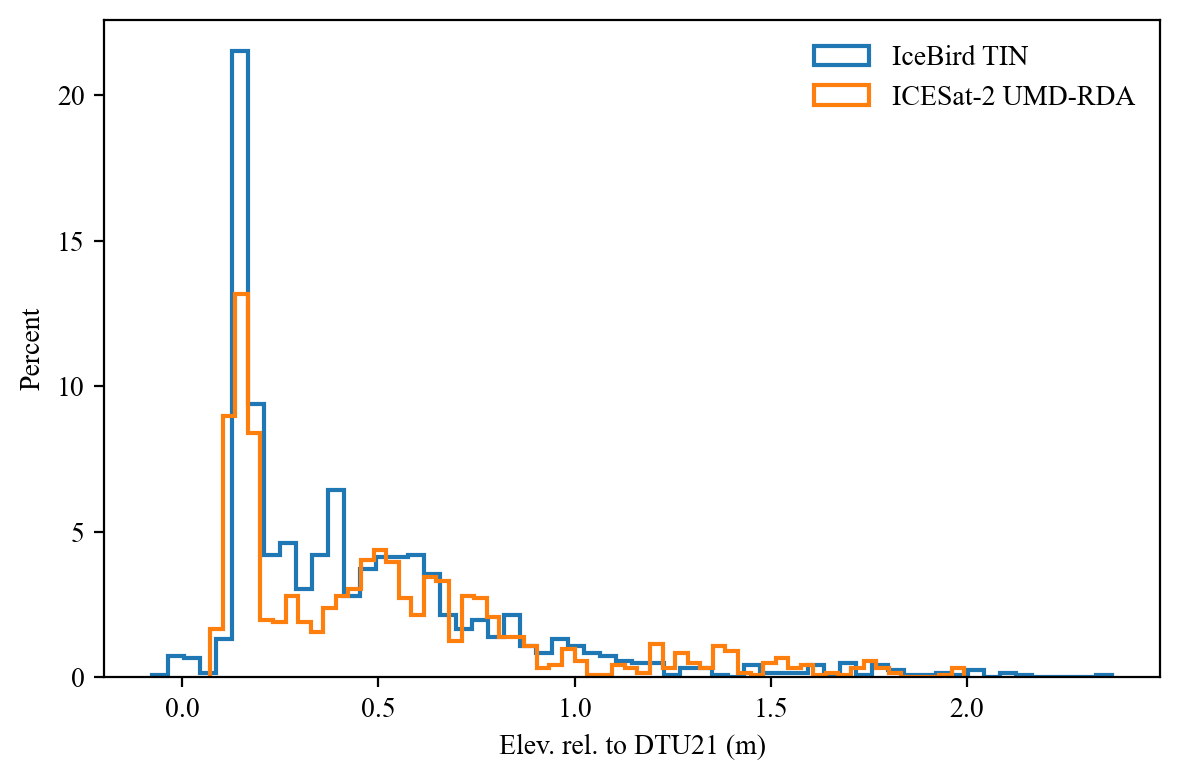

In [14]:
plt.rcParams.update({
    "font.family": "Times New Roman",
    "figure.dpi": 200
})

fig, ax = plt.subplots(figsize=(6, 4))

bins = 60

# Convert counts to percent using weights
weights_is2 = np.ones_like(z_is2_clean) * 100 / len(z_is2_clean)
weights_oib = np.ones_like(z_oib_clean) * 100 / len(z_oib_clean)

ax.hist(z_oib_clean, bins=bins, weights=weights_oib,
        histtype="step", linewidth=1.5, label="IceBird TIN")

ax.hist(z_is2_clean, bins=bins, weights=weights_is2,
        histtype="step", linewidth=1.5, label="ICESat-2 UMD-RDA")

ax.set_xlabel("Elev. rel. to DTU21 (m)")
ax.set_ylabel("Percent")
ax.legend(frameon=False)

plt.tight_layout()
# plt.savefig("C:/Users/yhqian/OneDrive - University of Maryland/PhD_study/Graphs and Tables/SeaIce/Graphs/PDF/ridges/evaluation_plot/ALS_L1B_20190410T174554_181213_3/UMDRDA_ATL03_ALS_L1B_20190410T174554_181213_3_dx0128.5_dy05.91_dz0.24_hist.pdf")
plt.show()

### 9) statistics of z values after cleanning

In [15]:
def compute_distribution_stats(z, bins=60):
    z = np.asarray(z)

    # basic statistics
    z_min = np.min(z)
    z_max = np.max(z)
    z_mean = np.mean(z)
    z_std = np.std(z)

    # histogram for percent-based mode
    counts, bin_edges = np.histogram(z, bins=bins)

    # find bin with highest count
    max_bin_index = np.argmax(counts)

    # mode = center of that bin
    mode_value = (bin_edges[max_bin_index] + bin_edges[max_bin_index + 1]) / 2

    return {
        "num": len(z),
        "min": z_min,
        "max": z_max,
        "mean": z_mean,
        "std": z_std,
        "mode": mode_value
    }

In [27]:
stats_is2 = compute_distribution_stats(z_is2, bins=60)
stats_oib = compute_distribution_stats(z_oib, bins=60)

print("ICESat-2:")
for k, v in stats_is2.items():
    print(f"{k}: {v:.3f}")

print("\nIceBird TIN:")
for k, v in stats_oib.items():
    print(f"{k}: {v:.3f}")

ICESat-2:
num: 1214.000
min: 0.071
max: 1.993
mean: 0.515
std: 0.399
mode: 0.151

IceBird TIN:
num: 1214.000
min: -0.076
max: 2.370
mean: 0.465
std: 0.375
mode: 0.148


In [16]:
stats_is2 = compute_distribution_stats(z_is2_clean, bins=60)
stats_oib = compute_distribution_stats(z_oib_clean, bins=60)

print("ICESat-2:")
for k, v in stats_is2.items():
    print(f"{k}: {v:.3f}")

print("\nIceBird TIN:")
for k, v in stats_oib.items():
    print(f"{k}: {v:.3f}")

ICESat-2:
num: 1214.000
min: 0.071
max: 1.993
mean: 0.515
std: 0.399
mode: 0.151

IceBird TIN:
num: 1214.000
min: -0.076
max: 2.370
mean: 0.465
std: 0.375
mode: 0.148


### 10) a helper function for plotting the profiles with peaks

In [21]:
def plot_profiles_with_peaks(
    df_is2_line,
    df_oib_line,
    df_is2_peaks,
    df_oib_peaks,
    xmin,
    xmax
):
    """
    Plot ICESat-2 and IceBridge elevation profiles with detected peaks.

    Parameters
    ----------
    df_is2_line : DataFrame
        Must contain columns ['distance', 'z']
    df_oib_line : DataFrame
        Must contain columns ['distance', 'z']
    df_is2_peaks : DataFrame
        Must contain columns ['distance', 'z']
    df_oib_peaks : DataFrame
        Must contain columns ['distance', 'z']
    xmin : float
        Minimum x-axis limit
    xmax : float
        Maximum x-axis limit
    """

    plt.rcParams.update({
        "font.family": "Times New Roman",
        "figure.dpi": 1200,
    })

    fig, ax = plt.subplots(figsize=(10, 4))

    # Lines
    ax.plot(
        df_is2_line["distance"],
        df_is2_line["z"],
        label="ICESat-2 profile",
        linewidth=1.0,
        antialiased=True,
        color="tab:orange",
    )

    ax.plot(
        df_oib_line["distance"],
        df_oib_line["z"],
        label="IceBridge TIN",
        linewidth=1.0,
        antialiased=True,
        color="tab:blue",
    )

    # Scatter peaks
    ax.scatter(
        df_is2_peaks["distance"],
        df_is2_peaks["z"],
        s=30,
        label="ICESat-2 peaks",
        zorder=5,
        color="tab:orange",
    )

    ax.scatter(
        df_oib_peaks["distance"],
        df_oib_peaks["z"],
        s=30,
        label="IceBird peaks",
        zorder=5,
        color="tab:blue",
    )

    ax.set_xlabel("Distance along the ICESat-2 track (m)", fontsize=12)
    ax.set_ylabel("Elev. rel. to DTU21 (m)", fontsize=12)
    ax.legend(prop={"size": 10})
    ax.grid(True, alpha=0.25)

    # Set x-limits from input parameters
    ax.set_xlim(xmin, xmax)

    plt.tight_layout()
    plt.show()

### 11) compute pearson coefficients

In [22]:
# keep only distance and z
df_is2_tmp = df_is2_line_cp[["distance","z"]].rename(columns={"z":"z_is2"})
df_oib_tmp = df_oib_line[["distance","z"]].rename(columns={"z":"z_oib"})

print("length of df_is2_tmp before merge:", len(df_is2_tmp))
print("length of df_oib_tmp before merge:", len(df_oib_tmp))

# merge by nearest distance (if grids are slightly different)
df_merged = pd.merge_asof(
    df_is2_tmp.sort_values("distance"),
    df_oib_tmp.sort_values("distance"),
    on="distance",
    direction="nearest",
    tolerance=0.5  # meters tolerance
)

df_merged = df_merged.dropna()
print("length of df_merged:", len(df_merged))

length of df_is2_tmp before merge: 1214
length of df_oib_tmp before merge: 1214
length of df_merged: 1214


In [23]:
diff = df_merged["z_oib"] - df_merged["z_is2"]

mean = diff.mean()
std  = diff.std()

mask = np.abs(diff - mean) <= 2 * std
df_clean = df_merged[mask]

In [25]:
from scipy import stats

r, p = stats.pearsonr(df_clean["z_is2"], df_clean["z_oib"])

mean_diff = np.mean(diff)
mode_diff = stats.mode(np.round(diff, 2), keepdims=True)[0][0]
std_diff  = np.std(diff)
diff_range = (np.min(diff), np.max(diff))

print(f"r: {r:.2f}, p: {p:.5g}")
print(f"mean diff: {mean_diff:.2f}")
print(f"diff range: {diff_range}")
print(f"mode diff: {mode_diff:.2f}")
print(f"diff sd: {std_diff:.2f}")

r: 0.91, p: 0
mean diff: -0.05
diff range: (-1.2232726389600632, 1.1143877100061599)
mode diff: 0.03
diff sd: 0.24


### 12) plot density map

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, pearsonr

def hist_mode(values, bin_width=0.01, vmin=None, vmax=None):
    """Histogram-based mode (robust for continuous values)."""
    v = np.asarray(values)
    v = v[np.isfinite(v)]
    if vmin is None: vmin = v.min()
    if vmax is None: vmax = v.max()
    bins = np.arange(vmin, vmax + bin_width, bin_width)
    h, edges = np.histogram(v, bins=bins)
    i = np.argmax(h)
    return 0.5 * (edges[i] + edges[i+1])

def density_scatter(ax, x, y, bw_method="scott", s=10):
    """
    Color each point by 2D kernel density estimate (KDE).
    Returns the PathCollection (for colorbar).
    """
    x = np.asarray(x); y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]; y = y[mask]

    xy = np.vstack([x, y])
    kde = gaussian_kde(xy, bw_method=bw_method)
    d = kde(xy)  # density per point

    # (optional) plot low-density points first so high-density shows on top
    idx = np.argsort(d)
    sc = ax.scatter(x[idx], y[idx], c=d[idx], s=s, linewidths=0, cmap="viridis")
    return sc

# -------------------------------
# Your data: replace these
# x = df_als["z_als"].to_numpy()
# y = df_rda["z_rda"].to_numpy()
# -------------------------------
# Example placeholders:
# x = ...
# y = ...

def plot_density_comparison(x, y, lim=(0, 2.5),
                            lead_max=0.15, ice_min=0.25,
                            bin_width=0.01):
    fig, ax = plt.subplots(figsize=(7.2, 6.2), dpi=150)

    # Density-colored scatter
    sc = density_scatter(ax, x, y, s=10)

    # 1:1 line
    ax.plot(lim, lim, "k--", lw=1.5)

    # Axes / labels / limits
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("ALS Elevation relative to DTU21 MSS (m)")
    ax.set_ylabel("UMD-RDA Elevation relative to DTU21 MSS (m)")
    ax.grid(True, alpha=0.4)

    # Colorbar
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Density")

    # Pearson r
    mask = np.isfinite(x) & np.isfinite(y)
    r, p = pearsonr(np.asarray(x)[mask], np.asarray(y)[mask])
    ax.text(0.60, 0.28, f"r = {r:.2f}", transform=ax.transAxes, fontsize=14)

    # ---- Modes (example logic) ----
    # "Lead elevations" mode: use small elevations (you can tune thresholds)
    x_lead = np.asarray(x)[mask]
    y_lead = np.asarray(y)[mask]
    lead_sel = (x_lead <= lead_max) & (y_lead <= lead_max)
    if np.any(lead_sel):
        mx_lead = hist_mode(x_lead[lead_sel], bin_width=bin_width)
        my_lead = hist_mode(y_lead[lead_sel], bin_width=bin_width)

        # horizontal callout line near y ~ mode
        ax.plot([lim[0] + 0.05, 0.45], [my_lead, my_lead], "k-", lw=3)
        ax.text(0.50, my_lead, "Mode of lead elevations", va="center",
                fontsize=14, weight="bold")

    # "Ice elevations" mode: a mid-elevation band (tune as needed)
    ice_sel = (x_lead >= ice_min) & (y_lead >= ice_min) & (x_lead <= 1.2) & (y_lead <= 1.2)
    if np.any(ice_sel):
        mx_ice = hist_mode(x_lead[ice_sel], bin_width=bin_width)
        my_ice = hist_mode(y_lead[ice_sel], bin_width=bin_width)

        ax.plot([0.25, 0.65], [my_ice, my_ice], "k-", lw=3)
        ax.text(0.70, my_ice, "Mode of ice elevations", va="center",
                fontsize=14, weight="bold")

    # ---- “Ridges” bracket-like annotation (simple version) ----
    # Draw a thick polyline to mimic the bracket in your example
    bx = [0.95, 1.05, 1.25, 1.65, 2.15, 2.40]
    by = [0.65, 0.72, 0.95, 1.30, 1.85, 2.15]
    ax.plot(bx, by, "k-", lw=4)

    # small "tick" on bracket
    ax.plot([1.65, 1.75], [1.30, 1.20], "k-", lw=4)

    ax.text(1.78, 1.25, "ridges", rotation=55, fontsize=14, weight="bold")

    plt.tight_layout()
    # plt.savefig("C:/Users/yhqian/OneDrive - University of Maryland/PhD_study/Graphs and Tables/SeaIce/Graphs/PDF/QGIS_partition_correlation/UMDRDA_ATL03_20190410152144_01890303_007_01_gt2l_DTU21_Elevation_epsg3413_drift_correct_dx0128.5_dy05.91_dz0.24_p3_correlation.pdf")
    return fig, ax

# Usage:
# fig, ax = plot_density_comparison(x, y)
# plt.show()

(<Figure size 1080x930 with 2 Axes>,
 <Axes: xlabel='ALS Elevation relative to DTU21 MSS (m)', ylabel='UMD-RDA Elevation relative to DTU21 MSS (m)'>)

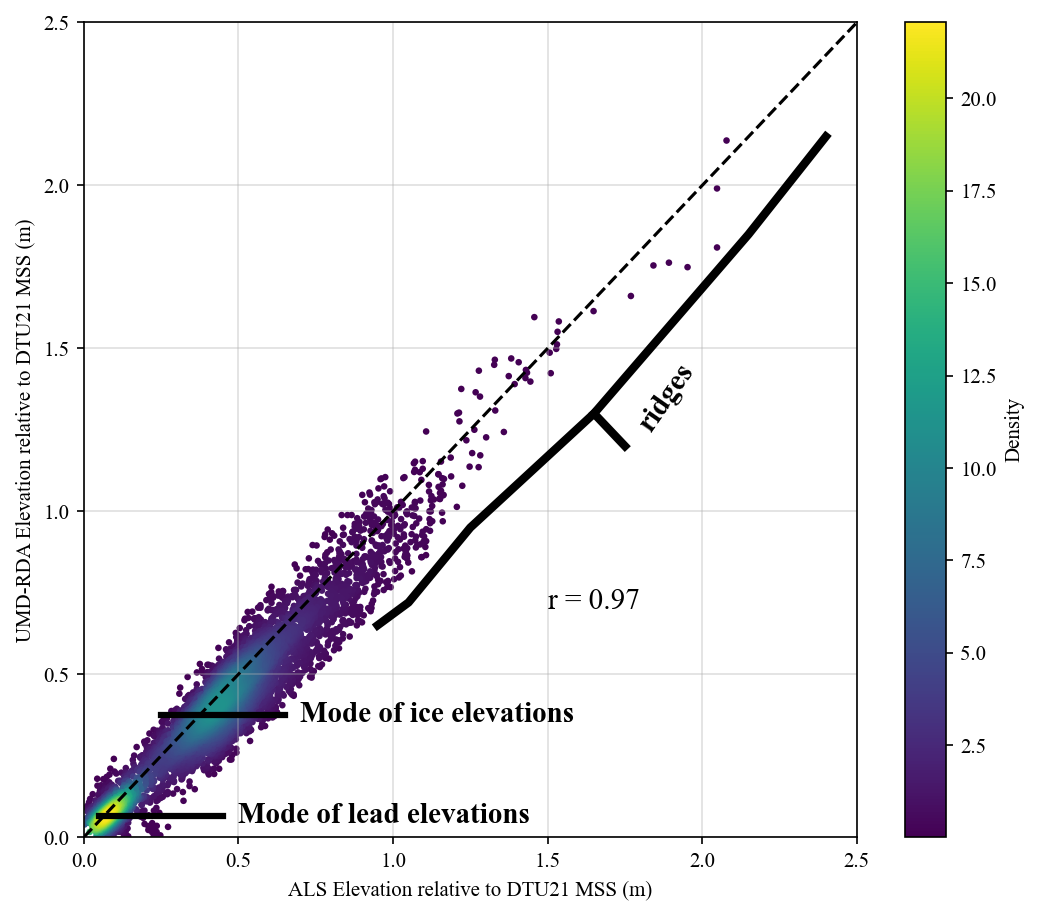

In [26]:
plot_density_comparison(df_clean["z_is2"], df_clean["z_oib"])